In [1]:
import os
import matplotlib.pyplot as plt
import torchvision
import torch
import pandas as pd
import numpy as np
import data_loaders
from torchvision import transforms
import torch
import utils

In [2]:
#import the dataset

majority_config = {'CUB_dir':r'CUB_200_2011',
                'split_file':r'CUB_200_2011/train_test_split.txt',
                'use_majority_voting':True,
                'min_class_count':10,
                'return_visibility':False}

#Center crop the image to 299x299 for Inception V3 and convert to tensor but do not normalize
transform = transforms.Compose([
    transforms.CenterCrop(299),
    transforms.ToTensor(), #implicitly divides by 255
    #transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [2, 2, 2])
    ])

dataset = data_loaders.CUB_dataset(config_dict=majority_config, mode='test', transform=transform)



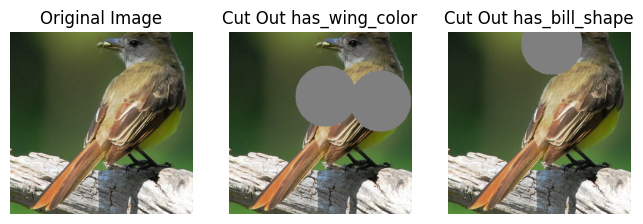

In [3]:


# Example: Visualize concept masking
Concept_idx_1 = 6
Concept_idx_2 = 2
id = 1020

x, c, y, cordinates = dataset[id]  # Get the image and its concept coordinates

# Cut out the concept using circular mask
x_cut_1, cut_exist_1 = utils.Concept_cut_out(x, cordinates, concept_idx=Concept_idx_1, size=100)
x_cut_2, cut_exist_2 = utils.Concept_cut_out(x, cordinates, concept_idx=Concept_idx_2, size=100)
# Visualize the original and cut-out images
fig, axs = plt.subplots(1, 3, figsize=(8, 4))
axs[0].imshow(np.transpose(x.numpy(), (1, 2, 0)))
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(np.transpose(x_cut_1.numpy(), (1, 2, 0)))
axs[1].set_title(f'Cut Out {dataset.consept_labels_names[Concept_idx_1].split("::")[0]}')
axs[1].axis('off')
axs[2].imshow(np.transpose(x_cut_2.numpy(), (1, 2, 0)))
axs[2].set_title(f'Cut Out {dataset.consept_labels_names[Concept_idx_2].split("::")[0]}')
axs[2].axis('off')
plt.show()

In [4]:
# Test the concept model with majority voting
XtoC_Model = torch.load(r'Models/ConceptModel__Seed1/outputs/best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()

CtoY_Model = torch.load(r'Models/IndependentModel_WithVal___Seed1/outputs/best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
CtoY_Model.eval()
CtoY_model = CtoY_Model.float()



/home/andreas/Desktop/WhyCBMsFails/venv/lib/python3.13/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.conv.Conv2d' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/home/andreas/Desktop/WhyCBMsFails/venv/lib/python3.13/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.batchnorm.BatchNorm2d' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/home/andreas/Desktop/WhyCBMsFails/venv/lib/python3.13/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.container.ModuleList' has ch

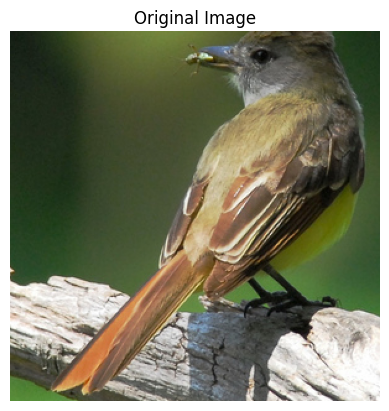

Image index: 1020  (img_id: 2132)
True class:      37 - 038.Great_Crested_Flycatcher
Predicted class: 37 - 038.Great_Crested_Flycatcher  (confidence: 1.000)
Concept accuracy (majority voting): 106/112
Concept accuracy (original): 75/112
Labels differ (original vs majority voting): 33/112


,Concept,Prediction,Pred (binary),True (original),True (majority voting),Vote Differs
0,has_bill_shape::dagger,-8.584,False,False,False,False
1,has_bill_shape::hooked_seabird,-8.328,False,False,False,False
2,has_bill_shape::all-purpose,5.544,True,True,True,False
3,has_bill_shape::cone,-5.991,False,False,False,False
4,has_wing_color::brown,-0.305,False,True,True,False
5,has_wing_color::grey,-2.122,False,False,False,False
6,has_wing_color::yellow,-5.622,False,False,False,False
7,has_wing_color::black,-2.818,False,True,False,True
8,has_wing_color::white,-5.257,False,False,False,False
9,has_wing_color::buff,-7.379,False,True,False,True


In [5]:
# Original image prediction
plt.imshow(np.transpose(x.numpy(), (1, 2, 0)))
plt.title('Original Image')
plt.axis('off')
plt.show()

with torch.no_grad():
    concept_preds_orig = torch.tensor(XtoC_Model(x.unsqueeze(0)))
    class_logits_orig = CtoY_Model(concept_preds_orig)
    pred_class_orig = torch.argmax(class_logits_orig).item()
    pred_conf_orig = torch.softmax(class_logits_orig, dim=0)[pred_class_orig].item()

df_orig = utils.print_prediction(dataset, id, concept_preds_orig, pred_class_orig, pred_conf_orig)

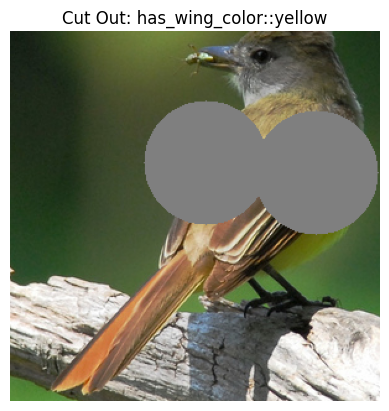

Image index: 1020  (img_id: 2132)
True class:      37 - 038.Great_Crested_Flycatcher
Predicted class: 199 - 200.Common_Yellowthroat  (confidence: 0.382)
Concept accuracy (majority voting): 95/112
Concept accuracy (original): 78/112
Labels differ (original vs majority voting): 33/112


,Concept,Prediction,Pred (binary),True (original),True (majority voting),200.Common_Yellowthroat (majority voting),Vote Differs
0,has_bill_shape::dagger,-6.304,False,False,False,False,False
1,has_bill_shape::hooked_seabird,-6.159,False,False,False,False,False
2,has_bill_shape::all-purpose,4.347,True,True,True,True,False
3,has_bill_shape::cone,-4.985,False,False,False,False,False
4,has_wing_color::brown,-2.059,False,True,True,False,False
5,has_wing_color::grey,-2.019,False,False,False,False,False
6,has_wing_color::yellow,-4.283,False,False,False,False,False
7,has_wing_color::black,-2.151,False,True,False,False,True
8,has_wing_color::white,-4.074,False,False,False,False,False
9,has_wing_color::buff,-5.805,False,True,False,False,True


In [6]:
# Cutout 1 prediction
plt.imshow(np.transpose(x_cut_1.numpy(), (1, 2, 0)))
plt.title(f'Cut Out: {dataset.consept_labels_names[Concept_idx_1]}')
plt.axis('off')
plt.show()

with torch.no_grad():
    concept_preds_cut1 = torch.tensor(XtoC_Model(x_cut_1.unsqueeze(0)))
    class_logits_cut1 = CtoY_Model(concept_preds_cut1)
    pred_class_cut1 = torch.argmax(class_logits_cut1).item()
    pred_conf_cut1 = torch.softmax(class_logits_cut1, dim=0)[pred_class_cut1].item()

df_cut1 = utils.print_prediction(dataset, id, concept_preds_cut1, pred_class_cut1, pred_conf_cut1, mispredict_class_idx=True)

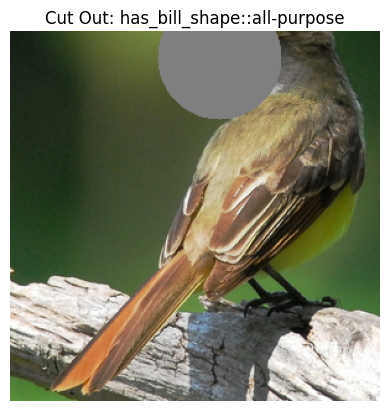

Image index: 1020  (img_id: 2132)
True class:      37 - 038.Great_Crested_Flycatcher
Predicted class: 37 - 038.Great_Crested_Flycatcher  (confidence: 1.000)
Concept accuracy (majority voting): 112/112
Concept accuracy (original): 79/112
Labels differ (original vs majority voting): 33/112


,Concept,Prediction,Pred (binary),True (original),True (majority voting),Vote Differs
0,has_bill_shape::dagger,-7.381,False,False,False,False
1,has_bill_shape::hooked_seabird,-7.184,False,False,False,False
2,has_bill_shape::all-purpose,4.797,True,True,True,False
3,has_bill_shape::cone,-5.805,False,False,False,False
4,has_wing_color::brown,1.133,True,True,True,False
5,has_wing_color::grey,-2.664,False,False,False,False
6,has_wing_color::yellow,-6.250,False,False,False,False
7,has_wing_color::black,-3.233,False,True,False,True
8,has_wing_color::white,-5.159,False,False,False,False
9,has_wing_color::buff,-6.813,False,True,False,True


In [7]:
# Cutout 2 prediction
plt.imshow(np.transpose(x_cut_2.numpy(), (1, 2, 0)))
plt.title(f'Cut Out: {dataset.consept_labels_names[Concept_idx_2]}')
plt.axis('off')
plt.show()

with torch.no_grad():
    concept_preds_cut2 = torch.tensor(XtoC_Model(x_cut_2.unsqueeze(0)))
    class_logits_cut2 = CtoY_Model(concept_preds_cut2)
    pred_class_cut2 = torch.argmax(class_logits_cut2).item()
    pred_conf_cut2 = torch.softmax(class_logits_cut2, dim=0)[pred_class_cut2].item()

df_cut2 = utils.print_prediction(dataset, id, concept_preds_cut2, pred_class_cut2, pred_conf_cut2)